In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = "Malgun Gothic"
mpl.rcParams['axes.unicode_minus'] = False

import torch
import torch.nn as nn
import torch.optim as optim

from torchviz import make_dot
import numpy as np

In [3]:
# 데이터 준비

# 라이브러리 임포트
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()

# 입력 데이터, 정답 데이터
x_org, y_org = iris.data, iris.target

# 결과 확인
print('원본 데이터', 'x_org.shape, y_org.shape')

원본 데이터 x_org.shape, y_org.shape


## 4차원 열 선택 추출

In [ ]:
# 입력 데이터에서 4차원 열 선택 추출
x_select = x_org[:, [0, 1, 2, 3]]
print('선택된 데이터', x_select.shape, y_org.shape)


선택된 데이터 (150, 4) (150,)


In [5]:
# 훈련 데이터와 검증 데이터로 분할(셔플도 동시에 실시함)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_select, y_org, train_size=75, test_size=75, 
    random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(75, 4) (75, 4) (75,) (75,)


In [6]:
# 데이터를 정답별로 분할

x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]
x_t2 = x_train[y_train == 2]

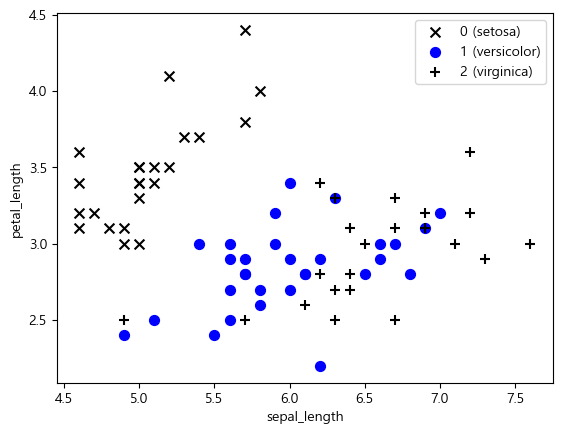

In [7]:
# 산포도 출력

plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='k', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='b', s=50, label='1 (versicolor)')
plt.scatter(x_t2[:,0], x_t2[:,1], marker='+', c='k', s=50, label='2 (virginica)')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

In [25]:
# 학습용 파라미터 설정

# 입력 차원수
n_input = x_train.shape[1]

# 출력 차원수
# 분류 클래스 수, 여기서는 4
n_output = len(list(set(y_train)))

# 결과 확인
print(f'n_input: {n_input}  n_output: {n_output}')

n_input: 4  n_output: 3


In [9]:
# 모델 정의
# 2입력 3출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)
                
        # 초깃값을 모두 1로 함
        # "딥러닝을 위한 수학"과 조건을 맞추기 위한 목적        
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    def forward(self, x):
        x1 = self.l1(x)
        return x1
    # forward() 메서드에서 활성화 함수를 사용하지 않음

# 인스턴스 생성
net = Net(n_input, n_output)        

In [10]:
# 모델 내부 파라미터 확인
# l1.weight는 행렬, l1.bias는 벡터

for parameter in net.named_parameters():
    print(parameter)

('l1.weight', Parameter containing:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([1., 1., 1.], requires_grad=True))


In [11]:
print(net)

Net(
  (l1): Linear(in_features=4, out_features=3, bias=True)
)


In [12]:
# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 학습률
lr = 0.01

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

In [16]:
# x_train과 y_train의 텐서 변수화

inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).long()

# 검증 데이터의 텐서 변수화

inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).long()

In [17]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels)

In [19]:
# 예측 라벨 리스트를 취득하기 위해, 두번째 indices만을 취하면 된다
torch.max(outputs, 1)[1]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [20]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 평가 결과 기록
history = np.zeros((0,5))

In [ ]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):

    # 훈련 페이즈
    
    # 경사 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels)

    # 경사 계산
    loss.backward()
    
    # 파라미터 수정
    optimizer.step()

#### !!!!!!!!!!!!!!!!!!!!!
#   항상 1,1 을 써야함. 열과 행...? 떄문
    # 예측 라벨 산출 * * *
    predicted = torch.max(outputs, 1)[1]

    # 손실과 정확도 계산
    train_loss = loss.item()
    train_acc = (predicted == labels).sum()  / len(labels)

    # 예측 페이즈

    # 예측 계산
    outputs_test = net(inputs_test)

    # 손실 계산
    loss_test = criterion(outputs_test, labels_test)

    # 예측 라벨 산출 * * *
    predicted_test = torch.max(outputs_test, 1)[1]

    # 손실과 정확도 계산
    val_loss =  loss_test.item()
    val_acc =  (predicted_test == labels_test).sum() / len(labels_test)
    
    if ((epoch) % 100 == 0):
        print (f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [0/10000], loss: 1.09861 acc: 0.30667 val_loss: 1.09158, val_acc: 0.26667
Epoch [100/10000], loss: 0.72750 acc: 0.76000 val_loss: 0.72494, val_acc: 0.69333
Epoch [200/10000], loss: 0.60292 acc: 0.90667 val_loss: 0.59273, val_acc: 0.84000
Epoch [300/10000], loss: 0.53859 acc: 0.93333 val_loss: 0.52605, val_acc: 0.90667
Epoch [400/10000], loss: 0.49666 acc: 0.94667 val_loss: 0.48340, val_acc: 0.90667
Epoch [500/10000], loss: 0.46553 acc: 0.96000 val_loss: 0.45221, val_acc: 0.90667
Epoch [600/10000], loss: 0.44057 acc: 0.96000 val_loss: 0.42753, val_acc: 0.92000
Epoch [700/10000], loss: 0.41961 acc: 0.96000 val_loss: 0.40701, val_acc: 0.92000
Epoch [800/10000], loss: 0.40146 acc: 0.96000 val_loss: 0.38939, val_acc: 0.93333
Epoch [900/10000], loss: 0.38543 acc: 0.97333 val_loss: 0.37394, val_acc: 0.94667
Epoch [1000/10000], loss: 0.37106 acc: 0.97333 val_loss: 0.36017, val_acc: 0.96000
Epoch [1100/10000], loss: 0.35805 acc: 0.97333 val_loss: 0.34776, val_acc: 0.96000
Epoch [1200/1000

## 실습 문제 01

In [22]:
# 1. 손실과 정확도 변화 확인

print(f'초기상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기상태 : 손실 : 1.09158  정확도 : 0.26667
최종상태 : 손실 : 0.13767  정확도 : 0.96000


## 실습문제 02

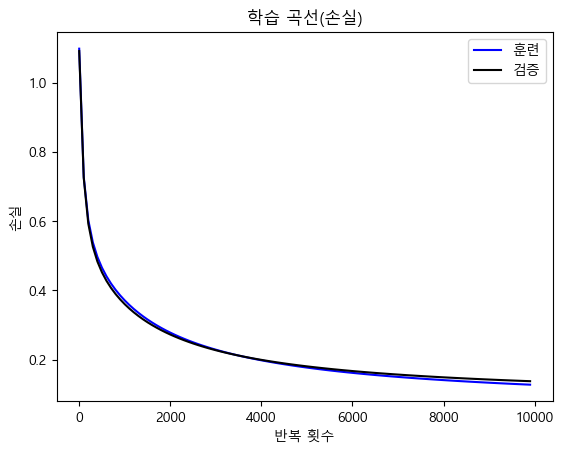

In [23]:
# 2. 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

## 실습문제 03

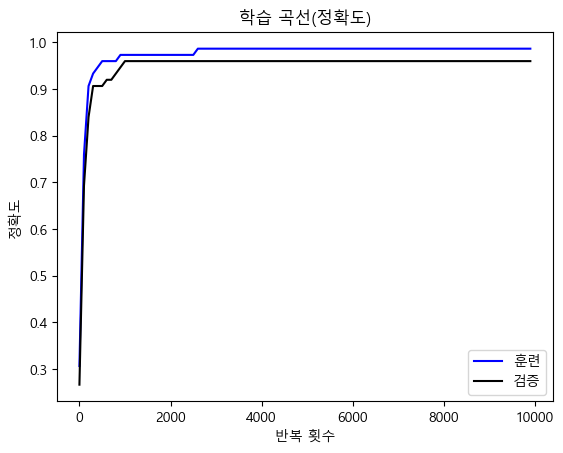

In [24]:
# 3. 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

## 실습문제 04

2차원으로 했을 때보다 4차원으로 했을 때, 정보량이 더 많아서
### 손실이 더 적고, 정확도도 더 높다.


4차원 특징벡터를 사용하면 꽃받침 너비(sepal width)와 꽃잎 너비(petal width) 정보가 추가되어 모델이 클래스를 더 잘 구분할 수 있게 된다.